In [1]:
from src import extract_text_from_cupt, export_to_jsonl
import pandas as pd
import matplotlib as plt
from collections import Counter
import arabic_reshaper
from bidi.algorithm import get_display

In [2]:
raw_data = "data/raw/"
processed_data = "data/processed/"

data = extract_text_from_cupt(raw_data + "train.cupt")
export_to_jsonl(data, processed_data + "train.jsonl")

data_df = pd.read_json(processed_data + "train.jsonl", lines=True)
data_df.head()

,sentence,mwes
0,ايران تعلن عن اختبار جديد ناجح لصاروخ شهاب 3,"[{'type': 'LVC.full', 'tokens': [{'text': 'تعل..."
1,وأكد النواب أن إجراء مفاوضات مع إسرائيل لتصدير...,"[{'type': 'LVC.full', 'tokens': [{'text': 'إجر..."
2,القاهرة 3 مايو,[]
3,تضم ليبيا ومصر ونيجيريا و التشاد,[]
4,وقال إن كمية التعاقد تبلغ 35 ألف متر مربع.,[]


In [3]:
# sentences with at least one mwe
mwe_sentences_df = data_df[data_df["mwes"].apply(len) > 0]

print(f"total number of sentences {len(data_df)}")
print(f"sentences with mwe {len(mwe_sentences_df)}")
print(
    f"percentage of sentences with mwes {len(mwe_sentences_df) / len(data_df) * 100:.2f}%"
)

total number of sentences 6091
sentences with mwe 2570
percentage of sentences with mwes 42.19%


In [4]:
total_mwes = data_df["mwes"].apply(len).sum()
print(f"total mwes: {total_mwes}")

total mwes: 3841


discontinous mwes: 1606


Text(0.5, 1.0, 'Proportion of Discontinuous MWEs')

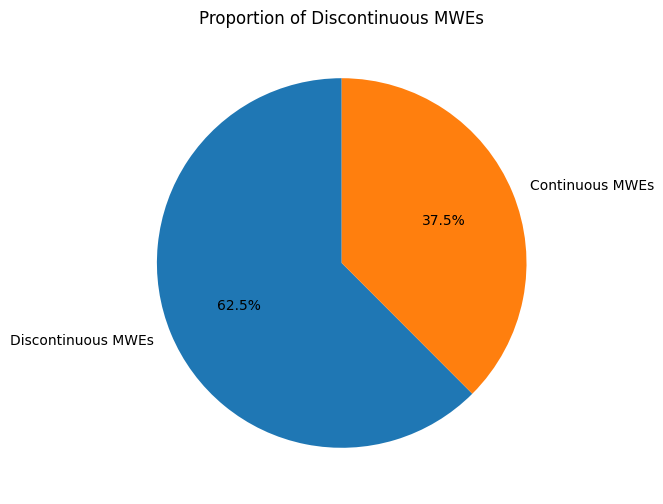

In [5]:
# check for disconintuity (interning tokens)
all_types = []
discontinous_mwe_count = 0

# how mnay non-mwe words interrupting mwe
gap_lengths = []

# window size: distance between first and last word in the mwe
span_lengths = []

# mwe words counts
mwe_word_counts = [] 

# most frquent lemmas
lemma_counts = Counter()

# mosyt frequent verbs
verb_counts = Counter()

for mwes_list in data_df["mwes"]:
    for mwe in mwes_list:
        mwe_word_counts.append(len(mwe["tokens"]))

        for token in mwe["tokens"]:
            lemma_counts[token["lemma"]] += 1
            if token["pos"] == "VERB":
                verb_counts[token["lemma"]] += 1
        
        all_types.append(mwe["type"])
        indices = sorted([int(token["index"]) for token in mwe["tokens"]])

        if len(indices) > 1 and indices[-1] - indices[0] + 1 > len(indices):
            discontinous_mwe_count += 1

        if (len(indices)) > 1:
            span = indices[-1] - indices[0]
            gap = span - len(indices) + 1

            # if continous mwe
            if gap > 0:
                gap_lengths.append(gap)
                span_lengths.append(span)

print(f"discontinous mwes: {discontinous_mwe_count}")

continous_mwe_count = len(mwe_sentences_df) - discontinous_mwe_count

continousity_data = pd.Series(
    [discontinous_mwe_count, continous_mwe_count],
    index=["Discontinuous MWEs", "Continuous MWEs"],
)

continous_plt = continousity_data.plot(
    kind="pie", autopct="%1.1f%%", figsize=(6, 6), startangle=90
)
continous_plt.set_title("Proportion of Discontinuous MWEs")

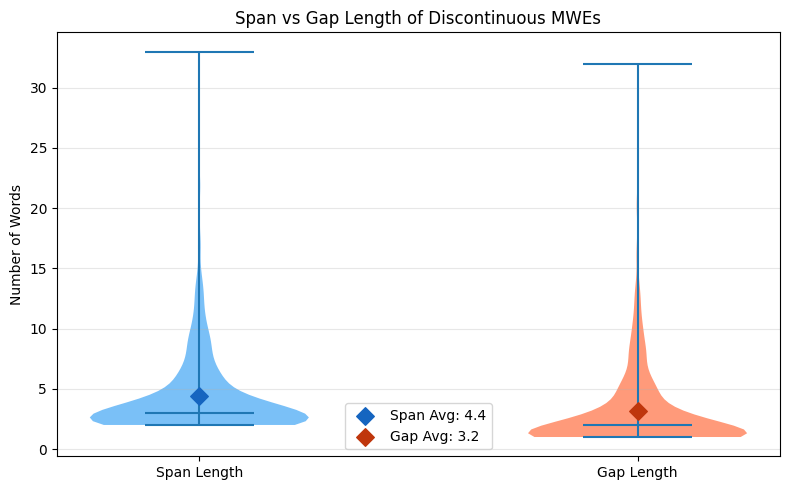

In [6]:
# plot the span of the mwe and the gap 
fig, ax = plt.pyplot.subplots(figsize=(8, 5))

parts = ax.violinplot([span_lengths, gap_lengths], showmedians=True)
parts['bodies'][0].set_facecolor('#2196F3')
parts['bodies'][1].set_facecolor('#FF5722')
for body in parts['bodies']:
    body.set_alpha(0.6)

# Calculate averages
span_avg = sum(span_lengths) / len(span_lengths)
gap_avg = sum(gap_lengths) / len(gap_lengths)

# Plot average as a marker + label
ax.scatter([1], [span_avg], color='#1565C0', zorder=5, s=80, marker='D', label=f'Span Avg: {span_avg:.1f}')
ax.scatter([2], [gap_avg], color='#BF360C', zorder=5, s=80, marker='D', label=f'Gap Avg: {gap_avg:.1f}')

ax.set_xticks([1, 2])
ax.set_xticklabels(['Span Length', 'Gap Length'])
ax.set_ylabel('Number of Words')
ax.set_title('Span vs Gap Length of Discontinuous MWEs')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.pyplot.tight_layout()
plt.pyplot.show()

In [7]:
# mwe type distribution
types_count = pd.Series(all_types).value_counts()
types_count

LVC.full     2178
VID           955
IAV           468
LVC.cause     236
MVC             4
Name: count, dtype: int64

Text(0, 0.5, 'Count')

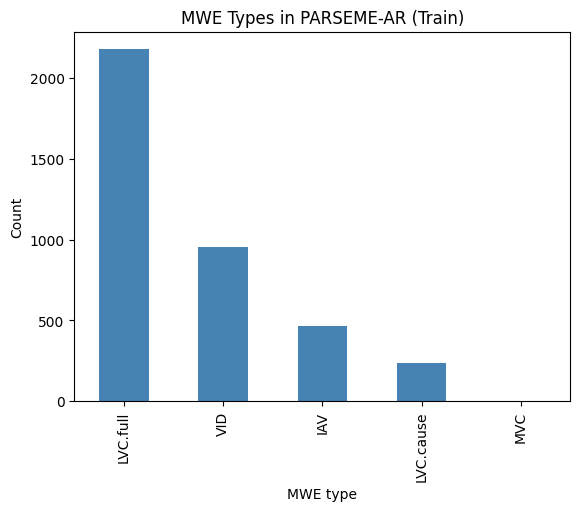

In [8]:
# plot the type distribution
type_distribution_plt = types_count.plot(
    kind="bar", title="MWE Types in PARSEME-AR (Train)", color="steelblue"
)
type_distribution_plt.set_xlabel("MWE type")
type_distribution_plt.set_ylabel("Count")

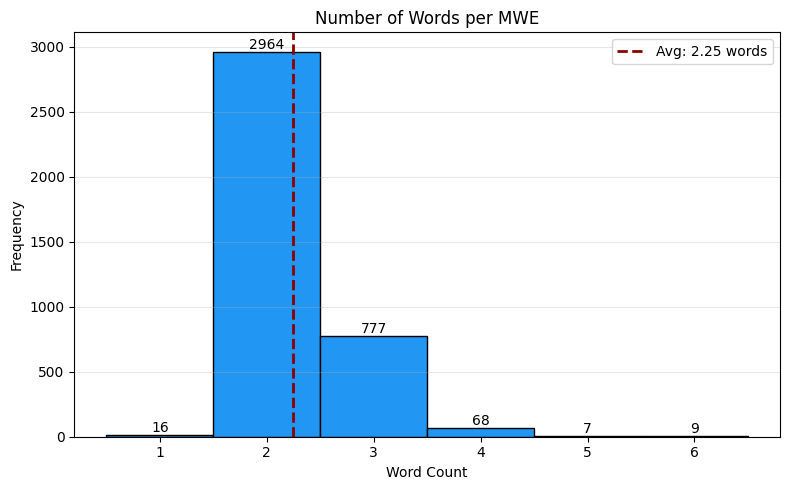

In [9]:
# mwe lengh (mwe word counts)
fig, ax = plt.pyplot.subplots(figsize=(8, 5))
ax.hist(
    mwe_word_counts,
    bins=range(min(mwe_word_counts), max(mwe_word_counts) + 2),
    color="#2196F3",
    edgecolor="black",
    align="left",
)

avg = sum(mwe_word_counts) / len(mwe_word_counts)
ax.axvline(
    avg, color="darkred", linestyle="--", linewidth=2, label=f"Avg: {avg:.2f} words"
)

ax.bar_label(ax.containers[0])
ax.set_title("Number of Words per MWE")
ax.set_xlabel("Word Count")
ax.set_ylabel("Frequency")
ax.set_xticks(range(min(mwe_word_counts), max(mwe_word_counts) + 1))
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.pyplot.tight_layout()
plt.pyplot.show()

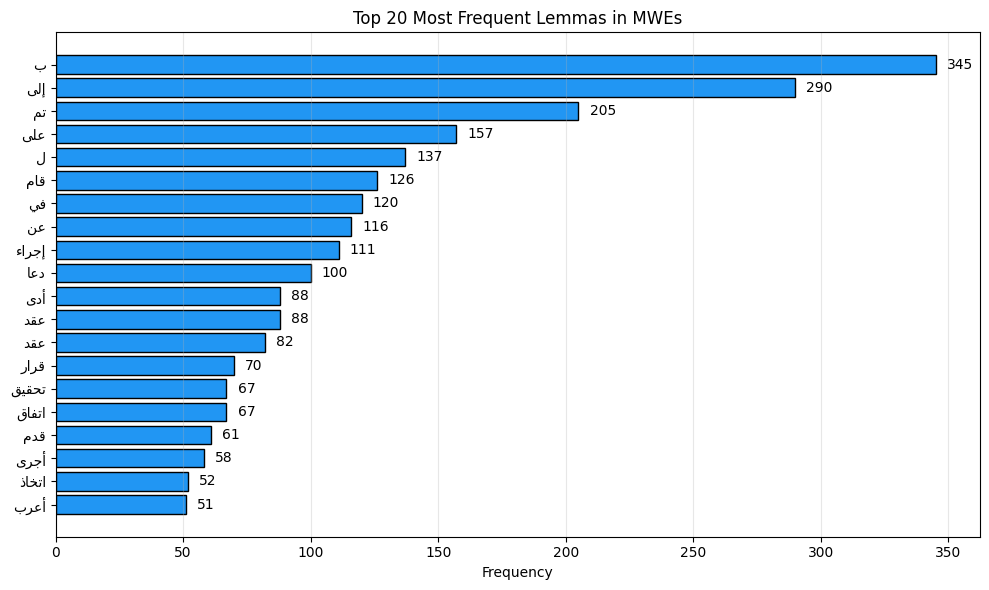

In [10]:
# top 20 most frequent lemmas
top_lemmas = lemma_counts.most_common(20)

labels_raw, values = zip(*top_lemmas)
labels = [get_display(arabic_reshaper.reshape(l)) for l in labels_raw]
fig, ax = plt.pyplot.subplots(figsize=(10, 6))
ax.barh(range(len(labels)), values, color="#2196F3", edgecolor="black")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Frequency")
ax.set_title("Top 20 Most Frequent Lemmas in MWEs")
ax.bar_label(ax.containers[0], padding=8)
ax.grid(axis="x", alpha=0.3)
plt.pyplot.tight_layout()
plt.pyplot.show()

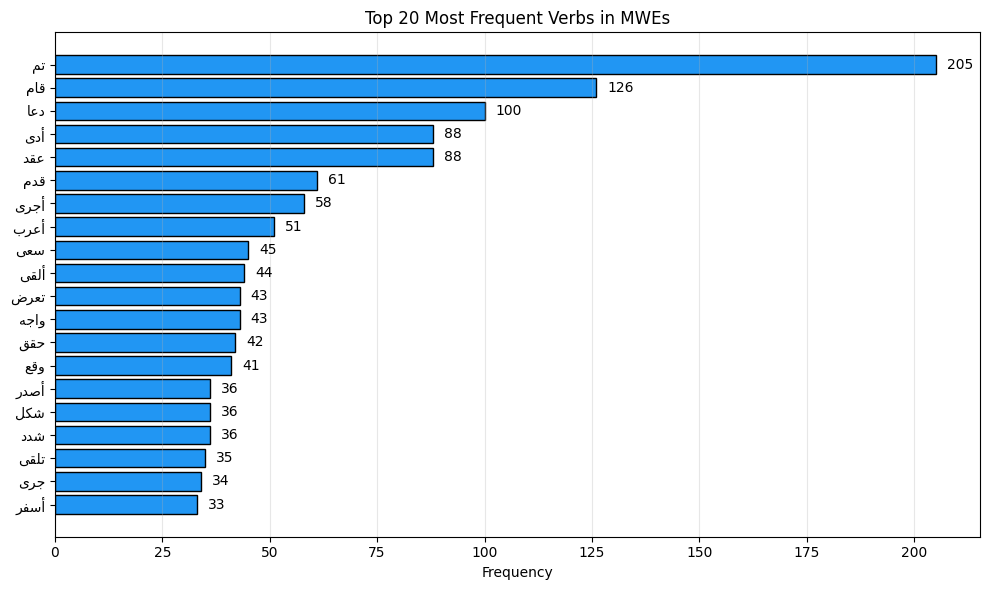

In [11]:
# top 20 frequent verb lemmas
top_verbs = verb_counts.most_common(20)
labels_raw, values = zip(*top_verbs)
labels = [get_display(arabic_reshaper.reshape(l)) for l in labels_raw]
fig, ax = plt.pyplot.subplots(figsize=(10, 6))
ax.barh(range(len(labels)), values, color='#2196F3', edgecolor='black')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('Frequency')
ax.set_title('Top 20 Most Frequent Verbs in MWEs')
ax.bar_label(ax.containers[0], padding=8)
ax.grid(axis='x', alpha=0.3)
plt.pyplot.tight_layout()
plt.pyplot.show()

In [ ]:
# count MWEs in each sentence and show the average
data_df["mwe_count"] = data_df["mwes"].apply(len)

avg_mwe = data_df["mwe_count"].mean()
print(f"Average number of MWEs per sentence: {avg_mwe:.4f}")
print(f"Max MWEs in a single sentence: {data_df['mwe_count'].max()}")
print(f"Median MWEs per sentence: {data_df['mwe_count'].median()}")

# plot the distribution
fig, ax = plt.pyplot.subplots(figsize=(8, 5))
ax.hist(
    data_df["mwe_count"],
    bins=range(0, data_df["mwe_count"].max() + 2),
    color="#2196F3",
    edgecolor="black",
    align="left",
)
ax.axvline(
    avg_mwe, color="darkred", linestyle="--", linewidth=2, label=f"Avg: {avg_mwe:.2f}"
)
ax.bar_label(ax.containers[0])
ax.set_title("Number of MWEs per Sentence")
ax.set_xlabel("MWE Count")
ax.set_ylabel("Number of Sentences")
ax.set_xticks(range(0, data_df["mwe_count"].max() + 1))
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.pyplot.tight_layout()
plt.pyplot.show()